# Counting duration at 200ps for QT3

In [1]:
import os
python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

# Test
!pip --version

pip 25.3 from C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip (python 3.14)



In [2]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [3]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

'2.3.3'

In [4]:
qd.start_client('192.168.3.1')

In [5]:
from logging import config


default_config = qd.NVConfiguration()

# Channels and pmods
default_config.mw_channel = 0
default_config.adc_channel = 0
default_config.laser_gate_pmod = 0 # should be 0 for PMOD0_0

# MW pulse parameters
default_config.mw_pi2_ftsamp = 131
default_config.mw_pi_ftsamp = default_config.mw_pi2_ftsamp * 2
default_config.mw_fMHz = 1846
default_config.mw_nqz = 1
default_config.mw_gain = 32767

# Delays
default_config.mw_to_laser_delay_tns = 555
default_config.relax_delay_tus = 2

# Readout
default_config.laser_on_tus = 4
default_config.readout_reference_start_tus = 3.5
default_config.readout_integration_tns = 340
default_config.laser_readout_offset_tus = 1.08

# Other
default_config.reps = 10000
default_config.pre_init = True
default_config.get_reference = True

# Photon Counting Params
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

In [6]:
qd.laser_on(copy(default_config))

2

In [7]:
qd.laser_off(copy(default_config))

0

In [8]:
from qickdawg.nvtestsuite.counting_duration_fine_res import CountingDurationFineRes

config = copy(default_config)

config.readout_integration_tns = 10
config.reps = 200000

delays = np.arange(800, 2200, 10)

def _as_scalar(value):
    arr = np.asarray(value).squeeze()
    if arr.size == 1:
        return float(arr)
    return float(np.mean(arr))

# # Basic practical fix: discard one dummy acquisition before storing data.
# config.laser_readout_offset_tns = int(delays[0])
# _ = CountingDurationFineRes(config).acquire()

results = None
for i in delays:
    config.laser_readout_offset_tns = int(i)

    prog = CountingDurationFineRes(config)
    d = prog.acquire()

    if results is None:
        results = copy(d)
        for key in d.keys():
            results[key] = np.empty(0, dtype=float)
        results.delay = np.empty(0, dtype=float)

    for key, value in d.items():
        results[key] = np.append(results[key], _as_scalar(value))
    results.delay = np.append(results.delay, config.laser_readout_offset_tus)


print(f"Stored {len(results.delay)} points.")

Stored 141 points.


In [9]:
delay_us = np.asarray(results.delay, dtype=float)

signal1_cts_s = np.asarray(
    getattr(results, "signal1_cts_s", getattr(results, "signal1")),
    dtype=float
)
signal2_cts_s = np.asarray(
    getattr(results, "signal2_cts_s", getattr(results, "signal2")),
    dtype=float
)

contrast = np.asarray(
    getattr(results, "contrast", signal1_cts_s / np.clip(signal2_cts_s, 1e-12, None)),
    dtype=float
)

n = min(len(delay_us), len(contrast), len(signal1_cts_s), len(signal2_cts_s))

df = pd.DataFrame({
    "delay_us": delay_us[:n],
    # "contrast": contrast[:n],
    "signal1_cts_s": signal1_cts_s[:n],
    "signal2_cts_s": signal2_cts_s[:n],
})

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def extract_from_df(df):
    cd_times = df["delay_us"].to_numpy() * 1e-6  # us -> s

    signal_off = df["signal1_cts_s"].to_numpy()  # was ON before
    signal_on = df["signal2_cts_s"].to_numpy()   # was OFF before

    return signal_on, signal_off, cd_times

def optimize_cd_df(df, t_min=0.0, threshold_pct=10.0):
    """
    Compute SNR vs integration time and find optimal readout duration,
    plus determine the switch-on time as the last point before the signal
    first rises above threshold_pct% of max counts/s.
    """
    signal_on, signal_off, cd_times = extract_from_df(df)

    # Apply time mask
    mask = cd_times >= t_min
    cd_times = cd_times[mask] - t_min
    signal_on = signal_on[mask]
    signal_off = signal_off[mask]

    subtracted = signal_on - signal_off

    snr_values = []

    for t in cd_times:
        mask_t = cd_times <= t

        # Integrate contrast and shot-noise for cumulative SNR curve.
        signal = np.trapezoid(subtracted[mask_t], cd_times[mask_t])
        noise = np.trapezoid(signal_on[mask_t] + signal_off[mask_t], cd_times[mask_t])

        snr = signal / np.sqrt(noise) if noise > 0 else 0.0
        snr_values.append(snr)

    snr_values = np.array(snr_values)

    # Ignore first point (same behavior as original code)
    max_idx = np.argmax(snr_values[1:]) + 1
    max_time = cd_times[max_idx]
    max_snr = snr_values[max_idx]

    # Threshold-based switch detection on raw subtracted signal.
    max_signal = np.max(subtracted)
    threshold = (threshold_pct / 100.0) * max_signal

    above_threshold = subtracted >= threshold
    if np.any(above_threshold):
        first_above_idx = np.where(above_threshold)[0][0]
        switch_idx = max(first_above_idx - 1, 0)
    else:
        switch_idx = 0

    switch_on_time = cd_times[switch_idx]
    switch_on_signal = subtracted[switch_idx]

    # SNR in the actual captured readout window [switch_on, switch_off].
    readout_mask = (cd_times >= switch_on_time) & (cd_times <= max_time)
    if np.count_nonzero(readout_mask) < 2:
        lo = min(switch_idx, max_idx)
        hi = max(switch_idx, max_idx)
        readout_mask = np.zeros_like(cd_times, dtype=bool)
        readout_mask[lo:hi + 1] = True

    signal_window = np.trapezoid(subtracted[readout_mask], cd_times[readout_mask])
    noise_window = np.trapezoid(
        signal_on[readout_mask] + signal_off[readout_mask],
        cd_times[readout_mask],
    )
    readout_window_snr = signal_window / np.sqrt(noise_window) if noise_window > 0 else 0.0

    print(f"Switch-on time = {switch_on_time:.3e} s (signal = {switch_on_signal:.1f} cts/s)")
    print(f"Max cumulative SNR = {max_snr:.3f} at t = {max_time:.3e} s")
    print(f"Readout duration = {(max_time - switch_on_time):.3e} s")
    print(f"Threshold used: {threshold:.1f} cts/s ({threshold_pct}% of max)")
    print(f"Readout-window SNR = {readout_window_snr:.3f}")

    # ---- Plot data ----
    fig_data, ax_data = plt.subplots(1, 2, figsize=(8, 6))

    ax_data[0].plot(cd_times, signal_on, label="signal 1 (on)")
    ax_data[0].plot(cd_times, signal_off, label="signal 2 (off)")
    ax_data[1].plot(cd_times, subtracted, label="on - off")

    ax_data[0].legend()
    ax_data[1].legend()

    ax_data[0].set_title("PL vs Time")
    ax_data[1].set_title("Subtracted Signal")

    for a in ax_data:
        a.grid(True)
        a.set_xlabel("Time (s)")
    ax_data[0].set_ylabel("Counts/s")

    # ---- Plot SNR ----
    fig_snr, ax_snr = plt.subplots()

    ax_snr.plot(cd_times, snr_values, label="SNR")
    ax_snr.axvline(
        switch_on_time,
        linestyle=":",
        color="orange",
        linewidth=2,
        label=f"RO start",
    )
    ax_snr.axvline(
        max_time,
        linestyle="--",
        color="red",
        linewidth=2,
        label=f"RO end",
    )

    # Inset text table matching summary output in the last cell.
    table_rows = [
        ("Readout Start", f"{switch_on_time * 1e6:.3f} us"),
        ("Readout End", f"{max_time * 1e6:.3f} us"),
        ("Readout Duration", f"{(max_time - switch_on_time) * 1e6:.3f} us"),
        ("Readout Window SNR", f"{readout_window_snr:.3f}"),
    ]
    left_width = max(len(k) for k, _ in table_rows)
    right_width = max(len(v) for _, v in table_rows)
    table_lines = [
        f"{'Optimal Parameters'.ljust(left_width)} | {'Value'.ljust(right_width)}",
        "-" * (left_width + right_width + 3),
    ]
    for k, v in table_rows:
        table_lines.append(f"{k.ljust(left_width)} | {v.rjust(right_width)}")
    table_text = "\n".join(table_lines)

    ax_snr.text(
        0.02,
        0.98,
        table_text,
        transform=ax_snr.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        family="monospace",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.3"},
    )

    ax_snr.set_xlabel("Integration Time (s)")
    ax_snr.set_ylabel("SNR")
    ax_snr.set_title("SNR vs Readout Duration")
    ax_snr.legend(loc="lower right")
    ax_snr.grid(True)

    return (
        switch_on_time,
        max_time,
        max_snr,
        readout_window_snr,
        switch_on_signal,
        fig_data,
        ax_data,
        fig_snr,
        ax_snr,
    )

Switch-on time = 1.178e-06 s (signal = 512.0 cts/s)
Max cumulative SNR = 0.065 at t = 1.602e-06 s
Readout duration = 4.232e-07 s
Threshold used: 10342.4 cts/s (10.0% of max)
Readout-window SNR = 0.066


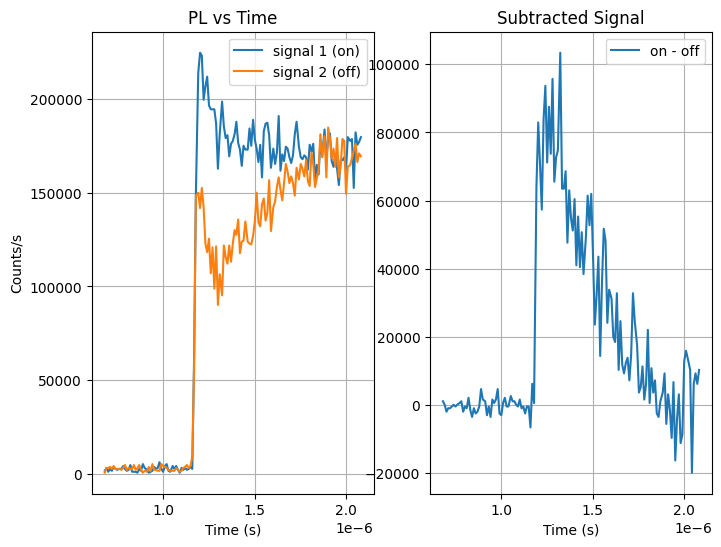

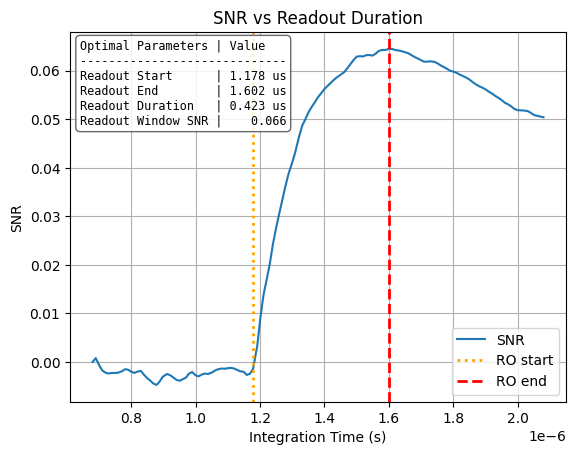

In [49]:
# optimize readout duration
switch_on_time, max_time, max_snr, readout_window_snr, switch_on_signal, *_ = optimize_cd_df(df)
plt.show()
